In [0]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, count, year, to_timestamp
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Create a Spark session named "CrimeAnalysis"
spark = SparkSession.builder.appName("CrimeAnalysis").getOrCreate()

# Fetch data from the API
url = 'https://www.phoenixopendata.com/api/3/action/datastore_search?resource_id=0ce3411a-2fc6-4302-a33f-167f68608a20&limit=5000'
response = requests.get(url)
data = response.json()

# Convert JSON data to Pandas DataFrame
records = data['result']['records']
df = pd.DataFrame(records)

# Convert Pandas DataFrame to Spark DataFrame
crime_data = spark.createDataFrame(df)

In [0]:
# Question 1: Most prevalent crime types in Phoenix, Arizona
prevalent_crimes = crime_data.groupBy("UCR CRIME CATEGORY").count().orderBy(col("count").desc())
prevalent_crimes.show(10, False)

+-------------------------------------+-----+
|UCR CRIME CATEGORY                   |count|
+-------------------------------------+-----+
|LARCENY-THEFT                        |2493 |
|BURGLARY                             |971  |
|MOTOR VEHICLE THEFT                  |634  |
|DRUG OFFENSE                         |318  |
|AGGRAVATED ASSAULT                   |295  |
|ROBBERY                              |178  |
|RAPE                                 |83   |
|ARSON                                |19   |
|MURDER AND NON-NEGLIGENT MANSLAUGHTER|9    |
+-------------------------------------+-----+



In [0]:
# Question 2: Crime hotspots in Phoenix, Arizona
def analyze_crime_hotspots(crime_data):
    hotspot_data = crime_data.groupBy("ZIP").agg(count("*").alias("Crime Count"))
    hotspot_data = hotspot_data.orderBy(col("Crime Count").desc())
    hotspot_data.show(40, False)

analyze_crime_hotspots(crime_data)

+-----+-----------+
|ZIP  |Crime Count|
+-----+-----------+
|85015|258        |
|85051|234        |
|85041|234        |
|85035|220        |
|85009|219        |
|85017|212        |
|85008|208        |
|85043|165        |
|85029|163        |
|85042|161        |
|85021|160        |
|85023|160        |
|85031|140        |
|85032|139        |
|85016|137        |
|85019|135        |
|85033|135        |
|85040|129        |
|85022|122        |
|85014|109        |
|85339|106        |
|85027|101        |
|85013|88         |
|85007|87         |
|85034|87         |
|85018|87         |
|85037|85         |
|85020|83         |
|85006|82         |
|85044|76         |
|85053|74         |
|85003|69         |
|85254|63         |
|85004|52         |
|85353|51         |
|85308|42         |
|85024|42         |
|85048|40         |
|85085|35         |
|85050|34         |
+-----+-----------+
only showing top 40 rows



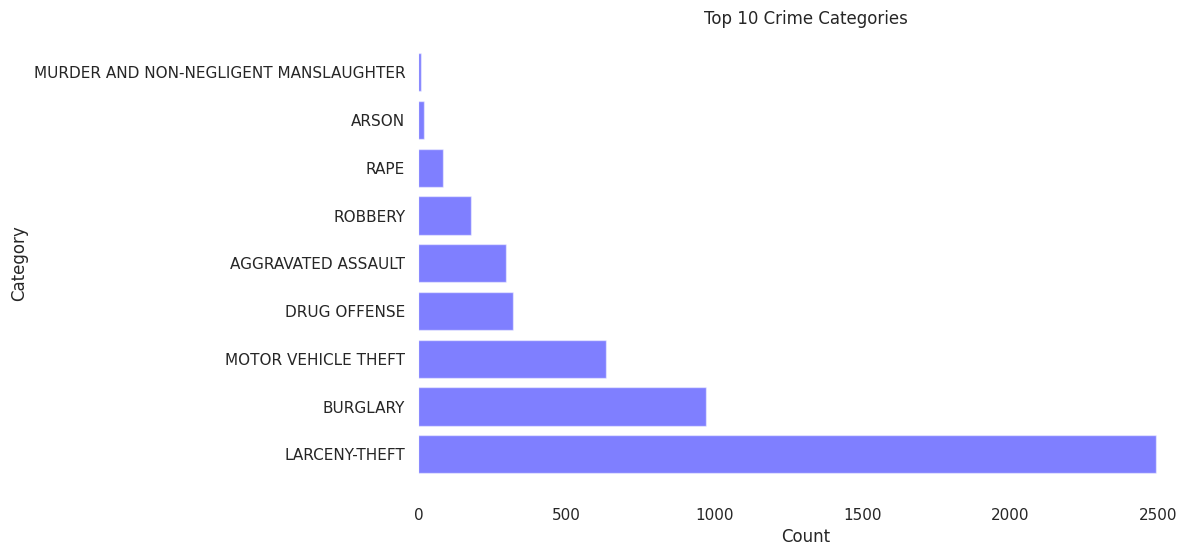

In [0]:
# Question 3: Temporal patterns of crime in Phoenix, Arizona
def analyze_temporal_patterns(crime_data):
    countcategory = crime_data.groupBy("UCR CRIME CATEGORY").count().alias("count").orderBy(col("count").desc())
    pandas_df = countcategory.toPandas()

    plt.barh(pandas_df["UCR CRIME CATEGORY"].head(10), pandas_df["count"].head(10), color='blue', alpha=0.5)
    plt.grid(False)
    plt.gca().set_facecolor('white')
    plt.title("Top 10 Crime Categories")
    plt.xlabel("Count")
    plt.ylabel("Category")
    plt.show()

analyze_temporal_patterns(crime_data)

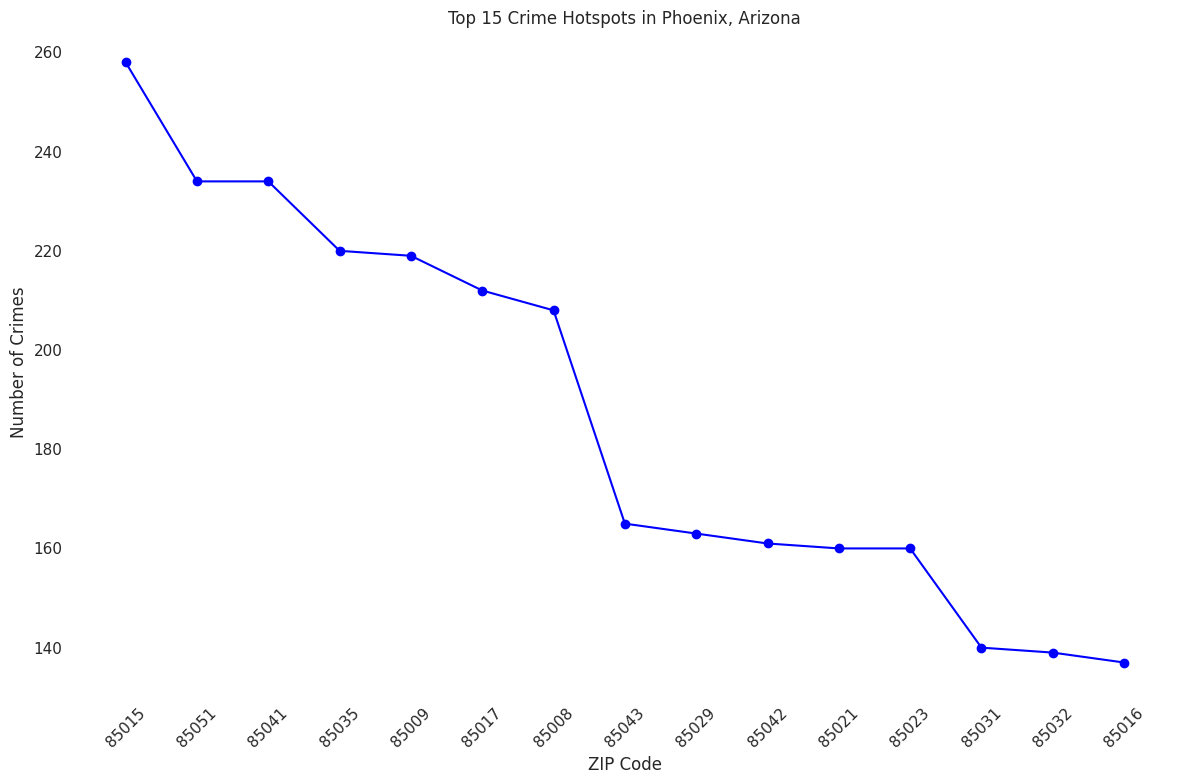

In [0]:
import matplotlib.pyplot as plt

def visualize_crime_hotspots_chart(hotspot_data):
    # Convert the Spark DataFrame to a Pandas DataFrame for plotting
    hotspot_pd = hotspot_data.orderBy(col("Crime Count").desc()).limit(15).toPandas()

    # Plotting
    plt.figure(figsize=(12, 8))
    plt.plot(hotspot_pd["ZIP"], hotspot_pd["Crime Count"], marker='o', color='blue', linestyle='-')
    plt.title('Top 15 Crime Hotspots in Phoenix, Arizona')
    plt.xlabel('ZIP Code')
    plt.ylabel('Number of Crimes')
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.gca().set_facecolor('white')  # Set plot background to white
    plt.tight_layout()
    plt.show()

# Assuming hotspot_data is already defined as the result of analyze_crime_hotspots function
visualize_crime_hotspots_chart(hotspot_data)